# Adversarially-Resilient Covert Multimedia Communication via Quantum-Inspired Embedding and AI-Driven Warden Modeling

This notebook implements and studies a methodology for covert multimedia communication under adversarial inspection. The objective is not only to hide a payload, but to do so while preserving image quality, enabling exact recovery, reducing feature-space divergence, and resisting AI-driven warden models.

### 1. Environment, imports, and mathematical support functions

This block prepares the computational environment, metrics, and utility functions needed to instantiate the optimization problem. It supports fidelity metrics, divergence proxies, projection-based diagnostics, and artifact export for reproducibility.

In [1]:
# Imports
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from PIL import Image

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

try:
    from skimage import data
except Exception:
    data = None

### 2. Reproducibility, paths, and experiment control

This block fixes seeds, configures output directories, and ensures the experiment can be reproduced either locally or in Colab/Drive environments.

In [2]:
# Reproducibility, paths, and optional Google Drive mount
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_NAME = "springer_cybersecurity_covert_comm"
BASE_LOCAL = Path("./outputs") / PROJECT_NAME
BASE_DRIVE = Path("/content/drive/MyDrive/Outputs") / PROJECT_NAME

if IN_COLAB:
    try:
        drive.mount('/content/drive')
        OUTPUT_DIR = BASE_DRIVE
    except Exception:
        OUTPUT_DIR = BASE_LOCAL
else:
    OUTPUT_DIR = BASE_LOCAL

FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
OTHER_DIR = OUTPUT_DIR / "others"
for p in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, OTHER_DIR]:
    p.mkdir(parents=True, exist_ok=True)

OUTPUT_SUMMARY = OTHER_DIR / "outputs_summary.txt"
print(f"Output directory: {OUTPUT_DIR.resolve()}")

Output directory: F:\MBZUAI UAE\10-SN-Quantum-Multimedia-Comm\outputs\springer_cybersecurity_covert_comm


### 3. Experimental configuration

This block defines the payload ratios $\rho$, whitening strengths $\alpha$, warden models, seed schedule, and trade-off weights used throughout the phase analysis.

In [3]:
# Configuration
CONFIG = {
    "image_size": 256,
    "payload_ratios": [0.01, 0.03, 0.05, 0.10, 0.15],
    "alpha_grid": [0.00, 0.25, 0.50, 0.75, 1.00],
    "alpha_representatives": [0.00, 0.50, 1.00],
    "alpha_smoke": 0.50,
    "n_variants_per_ratio": 36,
    "test_size": 0.30,
    "whitening_seed": 123,
    "rf_estimators": 300,
    "warden_models": ["logreg", "rf"],
    "save_figures": True,
    "basis_keep_prob": 0.62,
    "selector_jitter": 0.15,
    "position_shuffle_strength": 0.35,
    "analysis_seeds": [7, 21, 42, 84, 126],
    "stability_payload_ratios": [0.10, 0.15],
    "payload_constraint_min": 0.05,
    "tradeoff_weights": {
        "auc": 0.40,
        "divergence": 0.25,
        "distortion": 0.20,
        "payload_reward": 0.15,
    },
    "regime_bins": {
        "low": (0.00, 0.03),
        "medium": (0.03, 0.10),
        "high": (0.10, 1.00),
    },
}
CONFIG


{'image_size': 256,
 'payload_ratios': [0.01, 0.03, 0.05, 0.1, 0.15],
 'alpha_grid': [0.0, 0.25, 0.5, 0.75, 1.0],
 'alpha_representatives': [0.0, 0.5, 1.0],
 'alpha_smoke': 0.5,
 'n_variants_per_ratio': 36,
 'test_size': 0.3,
 'whitening_seed': 123,
 'rf_estimators': 300,
 'warden_models': ['logreg', 'rf'],
 'save_figures': True,
 'basis_keep_prob': 0.62,
 'selector_jitter': 0.15,
 'position_shuffle_strength': 0.35,
 'analysis_seeds': [7, 21, 42, 84, 126],
 'stability_payload_ratios': [0.1, 0.15],
 'payload_constraint_min': 0.05,
 'tradeoff_weights': {'auc': 0.4,
  'divergence': 0.25,
  'distortion': 0.2,
  'payload_reward': 0.15},
 'regime_bins': {'low': (0.0, 0.03),
  'medium': (0.03, 0.1),
  'high': (0.1, 1.0)}}

### 3b. Utility routines, metrics, and multi-objective analysis helpers

This block defines reusable functions for saving outputs, computing fidelity and recovery metrics, measuring divergence, normalizing quantities, and identifying Pareto-efficient operating points. These helpers keep the later experimental cells concise while making the optimization logic explicit.

In [4]:
# Helper utilities

def append_summary(text: str):
    with open(OUTPUT_SUMMARY, "a", encoding="utf-8") as f:
        f.write(text.rstrip() + "\n")

with open(OUTPUT_SUMMARY, "w", encoding="utf-8") as f:
    f.write("=== SPRINGER NOTEBOOK V6 (PUBLISHABLE-LEVEL, PEDAGOGICAL) ===\n")


def save_json(obj, path: Path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def save_df(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=False)


def save_fig(path: Path):
    if CONFIG["save_figures"]:
        plt.tight_layout()
        plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()


# =========================
# Metrics and diagnostics
# =========================

def mse_metric(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    return float(np.mean((img1 - img2) ** 2))


def psnr_from_mse(mse, max_val=255.0):
    if mse == 0:
        return float("inf")
    return float(10 * np.log10((max_val ** 2) / mse))


def ber_metric(bits_true, bits_pred):
    bits_true = np.array(bits_true).astype(np.uint8).ravel()
    bits_pred = np.array(bits_pred).astype(np.uint8).ravel()
    return float(np.mean(bits_true != bits_pred))


def safe_prob_hist(values: np.ndarray, bins: int = 24, value_range=None, eps: float = 1e-12):
    hist, _ = np.histogram(values.astype(np.float64), bins=bins, range=value_range, density=False)
    hist = hist.astype(np.float64) + eps
    hist /= hist.sum()
    return hist


def kl_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.asarray(p, dtype=np.float64) + eps
    q = np.asarray(q, dtype=np.float64) + eps
    p /= p.sum()
    q /= q.sum()
    return float(np.sum(p * np.log(p / q)))


def js_divergence(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.asarray(p, dtype=np.float64) + eps
    q = np.asarray(q, dtype=np.float64) + eps
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    return float(0.5 * kl_divergence(p, m) + 0.5 * kl_divergence(q, m))


def fisher_separation(X0: np.ndarray, X1: np.ndarray) -> float:
    mu0, mu1 = X0.mean(axis=0), X1.mean(axis=0)
    var0 = X0.var(axis=0) + 1e-12
    var1 = X1.var(axis=0) + 1e-12
    score = ((mu0 - mu1) ** 2) / (var0 + var1)
    return float(np.mean(score))


def pca_project_2d(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    return Xc @ Vt[:2].T


def minmax_normalize(values):
    values = np.asarray(values, dtype=np.float64)
    if np.allclose(values.max(), values.min()):
        return np.zeros_like(values, dtype=np.float64)
    return (values - values.min()) / (values.max() - values.min())


def composite_tradeoff_score(auc_norm, divergence_norm, distortion_norm, weights=None):
    if weights is None:
        weights = CONFIG["tradeoff_weights"]
    return (
        weights["auc"] * auc_norm
        + weights["divergence"] * divergence_norm
        + weights["distortion"] * distortion_norm
    )


def payload_aware_tradeoff_score(auc_norm, divergence_norm, distortion_norm, payload_norm, weights=None):
    if weights is None:
        weights = CONFIG["tradeoff_weights"]
    return (
        weights["auc"] * auc_norm
        + weights["divergence"] * divergence_norm
        + weights["distortion"] * distortion_norm
        - weights["payload_reward"] * payload_norm
    )


def pareto_efficient_mask(cost_matrix: np.ndarray) -> np.ndarray:
    cost_matrix = np.asarray(cost_matrix, dtype=np.float64)
    n = cost_matrix.shape[0]
    is_efficient = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_efficient[i]:
            continue
        dominates_i = np.all(cost_matrix <= cost_matrix[i], axis=1) & np.any(cost_matrix < cost_matrix[i], axis=1)
        if np.any(dominates_i):
            is_efficient[i] = False
    return is_efficient


def payload_regime_label(payload_ratio: float) -> str:
    if payload_ratio <= 0.03:
        return "low"
    if payload_ratio <= 0.10:
        return "medium"
    return "high"


### 4. Cover image preparation

This block loads the cover image $\mathbf{X}$ and standardizes it to a reproducible grayscale benchmark input.

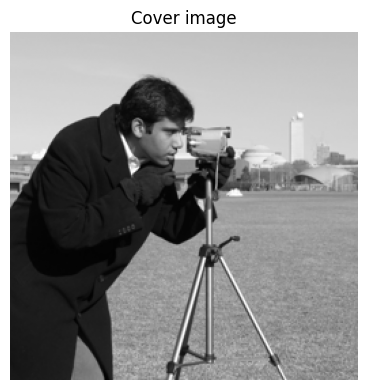

In [5]:
# Cover image loading

def load_cover_image(image_path: str | None = None, image_size: int = 256) -> np.ndarray:
    if image_path and Path(image_path).exists():
        img = Image.open(image_path).convert("L").resize((image_size, image_size))
        return np.array(img, dtype=np.uint8)

    if data is not None:
        img = Image.fromarray(data.camera()).convert("L").resize((image_size, image_size))
        return np.array(img, dtype=np.uint8)

    # Fallback synthetic image
    x = np.linspace(0, 255, image_size, dtype=np.uint8)
    img = np.tile(x, (image_size, 1))
    return img

cover = load_cover_image(image_size=CONFIG["image_size"])
plt.figure(figsize=(4, 4))
plt.imshow(cover, cmap="gray")
plt.title("Cover image")
plt.axis("off")
if CONFIG["save_figures"]:
    save_fig(FIG_DIR / "cover_image.png")
else:
    plt.show()
append_summary("Loaded cover image and initialized experiment.")

### 5. Controllable payload whitening and quantum-inspired stochastic selection

This block implements payload generation, tunable whitening $\mathbf{M}' = \mathbf{M} \oplus \mathbf{R}$, activity-aware suitability scoring, and stochastic position selection.

In [6]:
# Payload generation, partial whitening, and quantum-inspired selection

def generate_payload(num_bits: int, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.integers(0, 2, size=num_bits, dtype=np.uint8)


def whiten_payload(payload: np.ndarray, alpha: float = 1.0, seed: int = 123) -> tuple[np.ndarray, dict]:
    alpha = float(np.clip(alpha, 0.0, 1.0))
    payload = payload.astype(np.uint8).ravel()
    rng = np.random.default_rng(seed)
    random_mask = rng.integers(0, 2, size=payload.size, dtype=np.uint8)
    activation_mask = (rng.random(payload.size) < alpha).astype(np.uint8)
    applied_mask = np.bitwise_and(random_mask, activation_mask)
    whitened = np.bitwise_xor(payload, applied_mask)
    meta = {
        "alpha": alpha,
        "mask": applied_mask,
        "activation_mask": activation_mask,
    }
    return whitened, meta


def unwhiten_payload(payload_white: np.ndarray, whiten_meta: dict) -> np.ndarray:
    mask = np.asarray(whiten_meta["mask"], dtype=np.uint8)
    return np.bitwise_xor(payload_white.astype(np.uint8), mask).astype(np.uint8)


def quantum_basis_map(shape: tuple[int, int], p: float | None = None, seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    p = CONFIG["basis_keep_prob"] if p is None else p
    return rng.binomial(1, p, size=shape).astype(np.uint8)


def activity_map(img: np.ndarray) -> np.ndarray:
    imgf = img.astype(np.float32)
    gx = np.zeros_like(imgf)
    gy = np.zeros_like(imgf)
    gx[:, 1:] = np.abs(imgf[:, 1:] - imgf[:, :-1])
    gy[1:, :] = np.abs(imgf[1:, :] - imgf[:-1, :])
    act = gx + gy
    if act.max() > 0:
        act = act / act.max()
    return act


def selector_score(img: np.ndarray, basis: np.ndarray, strategy: str = "hybrid", seed: int | None = None) -> np.ndarray:
    rng = np.random.default_rng(seed)
    act = activity_map(img)
    texture_bonus = np.sqrt(np.clip(act, 0, 1))
    jitter = CONFIG["selector_jitter"] * rng.random(img.shape)

    if strategy == "fixed":
        score = 0.70 * basis + 0.20 * texture_bonus + 0.10 * jitter
    elif strategy == "adaptive":
        score = 0.25 * basis + 0.60 * texture_bonus + 0.15 * jitter
    else:
        score = 0.40 * basis + 0.40 * texture_bonus + 0.20 * jitter
    return score.astype(np.float32)


def select_positions(img: np.ndarray, num_bits: int, strategy: str = "hybrid", seed: int | None = None):
    rng = np.random.default_rng(seed)
    basis = quantum_basis_map(img.shape, seed=seed)
    score = selector_score(img, basis, strategy=strategy, seed=seed)

    eligible = np.flatnonzero(basis.ravel() == 1)
    if eligible.size < num_bits:
        eligible = np.arange(img.size)

    ranked = eligible[np.argsort(score.ravel()[eligible])[::-1]]
    top_pool_size = min(ranked.size, max(num_bits, int(num_bits * (1.0 + CONFIG["position_shuffle_strength"]))))
    top_pool = ranked[:top_pool_size]
    chosen = rng.choice(top_pool, size=num_bits, replace=False)
    rng.shuffle(chosen)

    rows, cols = np.unravel_index(chosen, img.shape)
    positions = np.column_stack([rows, cols]).astype(np.int32)
    return positions, basis, score


### 6. Parity-matching embedding and exact extraction

This block instantiates the embedding operator $\mathcal{E}(\mathbf{X}, \mathbf{M}, \theta, \alpha)$ and verifies lossless payload recovery through BER.

In [7]:
# Embedding and extraction

def parity_match_update(pixel_value: int, target_bit: int, rng) -> int:
    current_bit = pixel_value & 1
    if current_bit == int(target_bit):
        return int(pixel_value)

    if pixel_value == 0:
        return 1
    if pixel_value == 255:
        return 254

    direction = -1 if rng.random() < 0.5 else 1
    candidate = int(pixel_value) + direction
    if (candidate & 1) != int(target_bit):
        candidate = int(pixel_value) - direction
    return int(np.clip(candidate, 0, 255))


def embed_bits_lsb(img: np.ndarray, bits: np.ndarray, strategy: str = "hybrid", alpha: float = 0.0,
                   basis_seed: int = 42, whiten_seed: int = 123):
    img = img.copy().astype(np.uint8)
    bits = bits.astype(np.uint8).ravel()
    alpha = float(np.clip(alpha, 0.0, 1.0))

    if alpha > 0:
        bits_to_embed, whiten_meta = whiten_payload(bits, alpha=alpha, seed=whiten_seed)
    else:
        bits_to_embed, whiten_meta = bits.copy(), {"alpha": 0.0, "mask": np.zeros_like(bits, dtype=np.uint8)}

    positions, basis, score = select_positions(img, len(bits_to_embed), strategy=strategy, seed=basis_seed)
    stego = img.copy()
    rng = np.random.default_rng(basis_seed + 999)

    for idx, (r, c) in enumerate(positions):
        stego[r, c] = parity_match_update(int(stego[r, c]), int(bits_to_embed[idx]), rng)

    meta = {
        "positions": positions,
        "basis": basis,
        "score": score,
        "strategy": strategy,
        "alpha": alpha,
        "whiten_meta": whiten_meta,
        "capacity": len(bits_to_embed),
    }
    return stego, meta


def extract_bits_lsb(stego: np.ndarray, meta: dict, original_length: int) -> np.ndarray:
    positions = meta["positions"][:original_length]
    extracted = np.array([stego[r, c] & 1 for r, c in positions], dtype=np.uint8)
    whiten_meta = meta.get("whiten_meta")
    if whiten_meta is not None and float(meta.get("alpha", 0.0)) > 0:
        extracted = unwhiten_payload(extracted, whiten_meta)
    return extracted.astype(np.uint8)


### 7. Feature-based warden representation

This block constructs the statistical feature vector $\mathbf{f}(\mathbf{Z})$ used by the warden and prepares balanced cover/stego datasets for adversarial evaluation.

In [8]:
# Warden feature extraction and dataset builders

FEATURE_NAMES = [
    "mean_intensity",
    "std_intensity",
    "median_intensity",
    "q25_intensity",
    "q75_intensity",
    "grad_x_mean",
    "grad_y_mean",
    "grad_diag_mean",
    "grad_x_std",
    "grad_y_std",
    "lsb_mean",
    "lsb_transition_x",
    "lsb_transition_y",
]


def feature_vector(img: np.ndarray) -> np.ndarray:
    x = img.astype(np.float32)
    row_diff = np.abs(np.diff(x, axis=1))
    col_diff = np.abs(np.diff(x, axis=0))
    diag_diff = np.abs(x[1:, 1:] - x[:-1, :-1])
    lsb = (img & 1).astype(np.float32)

    features = [
        x.mean(),
        x.std(),
        np.median(x),
        np.percentile(x, 25),
        np.percentile(x, 75),
        row_diff.mean(),
        col_diff.mean(),
        diag_diff.mean(),
        row_diff.std(),
        col_diff.std(),
        np.mean(lsb),
        np.mean(lsb[:, 1:] != lsb[:, :-1]),
        np.mean(lsb[1:, :] != lsb[:-1, :]),
    ]
    return np.asarray(features, dtype=np.float32)


def build_dataset(cover: np.ndarray, payload_ratio: float, alpha: float, n_variants: int = 36, base_seed: int = 42):
    X, meta_rows = [], []
    n_bits = max(1, int(payload_ratio * cover.size))
    strategies = ["fixed", "adaptive", "hybrid"]
    cover_feat = feature_vector(cover)

    for i in range(n_variants):
        variant_seed = base_seed + i
        noise_rng = np.random.default_rng(10000 + variant_seed)
        bits = generate_payload(n_bits, seed=base_seed + 100 * i)
        strategy = strategies[i % len(strategies)]

        X.append(cover_feat + noise_rng.normal(0, 0.003, size=cover_feat.size))
        meta_rows.append({
            "class": "cover",
            "variant": "cover",
            "strategy": "none",
            "payload_ratio": payload_ratio,
            "alpha": 0.0,
            "seed": variant_seed,
        })

        stego, _ = embed_bits_lsb(
            cover,
            bits,
            strategy=strategy,
            alpha=alpha,
            basis_seed=variant_seed,
            whiten_seed=CONFIG["whitening_seed"] + i,
        )
        X.append(feature_vector(stego) + noise_rng.normal(0, 0.003, size=cover_feat.size))
        meta_rows.append({
            "class": "stego",
            "variant": f"alpha_{alpha:.2f}",
            "strategy": strategy,
            "payload_ratio": payload_ratio,
            "alpha": alpha,
            "seed": variant_seed,
        })

    return np.vstack(X), pd.DataFrame(meta_rows)


def feature_divergence_report(X: np.ndarray, meta_df: pd.DataFrame, target_alpha: float) -> dict:
    cover_mask = meta_df["class"].eq("cover").to_numpy()
    stego_mask = meta_df["class"].eq("stego").to_numpy() & np.isclose(meta_df["alpha"].to_numpy(dtype=float), float(target_alpha))

    X_cover = X[cover_mask]
    X_stego = X[stego_mask]

    cover_mean = X_cover.mean(axis=0)
    stego_mean = X_stego.mean(axis=0)

    mean_shift_l2 = float(np.linalg.norm(cover_mean - stego_mean))
    fisher = fisher_separation(X_cover, X_stego)

    p = safe_prob_hist(X_cover[:, 10], bins=20, value_range=(0, 1))
    q = safe_prob_hist(X_stego[:, 10], bins=20, value_range=(0, 1))
    js_lsb_mean = js_divergence(p, q)
    kl_cover_to_stego = kl_divergence(p, q)
    kl_stego_to_cover = kl_divergence(q, p)

    p2 = safe_prob_hist(X_cover[:, 11], bins=20, value_range=(0, 1))
    q2 = safe_prob_hist(X_stego[:, 11], bins=20, value_range=(0, 1))
    js_transition = js_divergence(p2, q2)

    feature_shift = np.abs(cover_mean - stego_mean)

    return {
        "alpha": float(target_alpha),
        "mean_shift_l2": mean_shift_l2,
        "fisher_separation": fisher,
        "js_lsb_mean": js_lsb_mean,
        "js_lsb_transition": js_transition,
        "kl_cover_to_stego": kl_cover_to_stego,
        "kl_stego_to_cover": kl_stego_to_cover,
        "delta_mean_intensity": float(feature_shift[0]),
        "delta_grad_x_mean": float(feature_shift[5]),
        "delta_grad_y_mean": float(feature_shift[6]),
        "delta_lsb_mean": float(feature_shift[10]),
    }


### 8. AI-driven warden modeling

This block trains the Logistic Regression and Random Forest wardens and evaluates detectability using accuracy and AUC.

In [9]:
# Adversarial evaluation

def evaluate_warden(X: np.ndarray, y: np.ndarray, model_name: str = "logreg", seed: int = 42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=CONFIG["test_size"], random_state=seed, stratify=y
    )

    if model_name == "logreg":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=seed))
        ])
    else:
        model = RandomForestClassifier(
            n_estimators=120,
            random_state=seed,
            max_depth=4,
            min_samples_leaf=4,
            max_features="sqrt",
            n_jobs=-1,
        )

    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    fpr, tpr, _ = roc_curve(y_test, prob)

    return {
        "model": model,
        "accuracy": float(accuracy_score(y_test, pred)),
        "auc": float(auc(fpr, tpr)),
        "fpr": fpr,
        "tpr": tpr,
    }


def evaluate_detection_for_alpha(X: np.ndarray, meta_df: pd.DataFrame, alpha: float, model_name: str = "logreg", seed: int = 42):
    idx = meta_df["class"].eq("cover") | (meta_df["class"].eq("stego") & np.isclose(meta_df["alpha"], alpha))
    X_sub = X[idx.to_numpy()]
    y_sub = (meta_df.loc[idx, "class"].to_numpy() == "stego").astype(int)
    return evaluate_warden(X_sub, y_sub, model_name=model_name, seed=seed)


### 9. Smoke test

This block performs a lightweight sanity check on one representative configuration before the full payload--whitening sweep.

In [10]:
# Single-ratio smoke test for partial whitening
payload_ratio = CONFIG["payload_ratios"][0]
alpha_smoke = CONFIG["alpha_smoke"]
X_smoke, meta_df_smoke = build_dataset(
    cover,
    payload_ratio=payload_ratio,
    alpha=alpha_smoke,
    n_variants=CONFIG["n_variants_per_ratio"],
    base_seed=SEED,
)

results = []
for model_name in CONFIG["warden_models"]:
    res = evaluate_detection_for_alpha(X_smoke, meta_df_smoke, alpha=alpha_smoke, model_name=model_name, seed=SEED)
    results.append({
        "alpha": alpha_smoke,
        "model": model_name,
        "payload_ratio": payload_ratio,
        "accuracy": res["accuracy"],
        "auc": res["auc"],
    })
    print(f"alpha={alpha_smoke:.2f}", model_name, res["accuracy"], res["auc"])

smoke_df = pd.DataFrame(results)
save_df(smoke_df, TABLE_DIR / "smoke_test_results_v4.csv")
append_summary("=== SMOKE TEST RESULTS ===")
append_summary(smoke_df.to_string(index=False))
smoke_df


alpha=0.50 logreg 0.5909090909090909 0.7272727272727273
alpha=0.50 rf 0.5909090909090909 0.7355371900826446


,alpha,model,payload_ratio,accuracy,auc
0,0.5,logreg,0.01,0.590909,0.727273
1,0.5,rf,0.01,0.590909,0.735537


### 10. Payload--whitening phase analysis, divergence analysis, and payload-aware operating-point selection

- **Recoverability:** whether the embedded payload can be recovered with zero BER.
- **Imperceptibility:** measured through MSE and PSNR.
- **Statistical invisibility:** measured through divergence proxies in feature space.
- **Adversarial detectability:** measured through AI-driven warden AUC.


In [11]:
# Payload sweep, alpha sweep, divergence proxies, sender--warden trade-off analysis, and robustness
records = []
divergence_records = []
quality_records = []
seed_records = []
roc_cache = {}

for ratio in CONFIG["payload_ratios"]:
    n_bits = max(1, int(ratio * cover.size))
    bits = generate_payload(n_bits, seed=SEED + int(1000 * ratio))

    for alpha in CONFIG["alpha_grid"]:
        X, meta_df = build_dataset(
            cover,
            payload_ratio=ratio,
            alpha=alpha,
            n_variants=CONFIG["n_variants_per_ratio"],
            base_seed=SEED,
        )

        stego, meta = embed_bits_lsb(
            cover,
            bits,
            strategy="hybrid",
            alpha=alpha,
            basis_seed=SEED,
            whiten_seed=CONFIG["whitening_seed"],
        )
        rec_bits = extract_bits_lsb(stego, meta, len(bits))
        mse = mse_metric(cover, stego)
        psnr = psnr_from_mse(mse)
        ber = ber_metric(bits, rec_bits)

        quality_records.append({
            "payload_ratio": ratio,
            "alpha": alpha,
            "mse": mse,
            "psnr": psnr,
            "ber": ber,
        })

        divergence = feature_divergence_report(X, meta_df, target_alpha=alpha)
        divergence["payload_ratio"] = ratio
        divergence_records.append(divergence)

        for model_name in CONFIG["warden_models"]:
            res = evaluate_detection_for_alpha(X, meta_df, alpha=alpha, model_name=model_name, seed=SEED)
            roc_cache[(ratio, alpha, model_name)] = res
            records.append({
                "payload_ratio": ratio,
                "payload_regime": payload_regime_label(ratio),
                "alpha": alpha,
                "model": model_name,
                "accuracy": res["accuracy"],
                "auc": res["auc"],
                "mse": mse,
                "psnr": psnr,
                "ber": ber,
                "mean_shift_l2": divergence["mean_shift_l2"],
                "fisher_separation": divergence["fisher_separation"],
                "js_lsb_mean": divergence["js_lsb_mean"],
                "js_lsb_transition": divergence["js_lsb_transition"],
                "kl_cover_to_stego": divergence["kl_cover_to_stego"],
                "kl_stego_to_cover": divergence["kl_stego_to_cover"],
                "delta_mean_intensity": divergence["delta_mean_intensity"],
                "delta_grad_x_mean": divergence["delta_grad_x_mean"],
                "delta_grad_y_mean": divergence["delta_grad_y_mean"],
                "delta_lsb_mean": divergence["delta_lsb_mean"],
            })

for ratio in CONFIG["stability_payload_ratios"]:
    for alpha in CONFIG["alpha_grid"]:
        for seed in CONFIG["analysis_seeds"]:
            X_seed, meta_df_seed = build_dataset(
                cover,
                payload_ratio=ratio,
                alpha=alpha,
                n_variants=CONFIG["n_variants_per_ratio"],
                base_seed=seed,
            )
            for model_name in CONFIG["warden_models"]:
                res_seed = evaluate_detection_for_alpha(X_seed, meta_df_seed, alpha=alpha, model_name=model_name, seed=seed)
                seed_records.append({
                    "payload_ratio": ratio,
                    "alpha": alpha,
                    "seed": seed,
                    "model": model_name,
                    "auc": res_seed["auc"],
                    "accuracy": res_seed["accuracy"],
                })

sweep_df = pd.DataFrame(records)
divergence_df = pd.DataFrame(divergence_records)
quality_df = pd.DataFrame(quality_records)
seed_stability_df = pd.DataFrame(seed_records)

# Baseline normalized costs
sweep_df["auc_excess"] = np.clip(sweep_df["auc"] - 0.5, 0, None)
sweep_df["inv_psnr"] = 1.0 / np.maximum(sweep_df["psnr"], 1e-9)
sweep_df["payload_norm"] = minmax_normalize(sweep_df["payload_ratio"])

sweep_df["auc_norm"] = minmax_normalize(sweep_df["auc_excess"])
sweep_df["divergence_proxy"] = 0.50 * sweep_df["mean_shift_l2"] + 0.30 * sweep_df["js_lsb_mean"] + 0.20 * sweep_df["fisher_separation"]
sweep_df["divergence_norm"] = minmax_normalize(sweep_df["divergence_proxy"])
sweep_df["distortion_norm"] = minmax_normalize(sweep_df["inv_psnr"])

# Legacy score kept for comparison
sweep_df["tradeoff_score_legacy"] = composite_tradeoff_score(
    sweep_df["auc_norm"],
    sweep_df["divergence_norm"],
    sweep_df["distortion_norm"],
)

# Payload-aware score: lower is better, larger payload is rewarded
sweep_df["tradeoff_score_payload_aware"] = payload_aware_tradeoff_score(
    sweep_df["auc_norm"],
    sweep_df["divergence_norm"],
    sweep_df["distortion_norm"],
    sweep_df["payload_norm"],
)

# Enforce realistic operating point selection
payload_min = CONFIG["payload_constraint_min"]
sweep_df["feasible_payload"] = sweep_df["payload_ratio"] >= payload_min
penalty = np.where(sweep_df["feasible_payload"], 0.0, 1.0)
sweep_df["tradeoff_score_constrained"] = sweep_df["tradeoff_score_payload_aware"] + penalty

tradeoff_df = (
    sweep_df.sort_values(
        ["payload_ratio", "model", "tradeoff_score_payload_aware", "auc", "psnr"],
        ascending=[True, True, True, True, False],
    )
    .groupby(["payload_ratio", "model"], as_index=False)
    .first()
    .rename(columns={"alpha": "alpha_star"})
)

alpha_summary_df = (
    sweep_df.groupby(["payload_ratio", "payload_regime", "alpha"], as_index=False)
    .agg({
        "auc": "mean",
        "psnr": "mean",
        "ber": "mean",
        "mean_shift_l2": "mean",
        "fisher_separation": "mean",
        "js_lsb_mean": "mean",
        "tradeoff_score_legacy": "mean",
        "tradeoff_score_payload_aware": "mean",
        "tradeoff_score_constrained": "mean",
    })
)

phase_best_df = (
    alpha_summary_df.sort_values(
        ["payload_ratio", "tradeoff_score_payload_aware", "auc", "psnr"],
        ascending=[True, True, True, False],
    )
    .groupby("payload_ratio", as_index=False)
    .first()
    .rename(columns={"alpha": "alpha_star_phase"})
)

phase_best_realistic_df = (
    alpha_summary_df[alpha_summary_df["payload_ratio"] >= payload_min]
    .sort_values(
        ["payload_ratio", "tradeoff_score_constrained", "auc", "psnr"],
        ascending=[True, True, True, False],
    )
    .groupby("payload_ratio", as_index=False)
    .first()
    .rename(columns={"alpha": "alpha_star_realistic"})
)

seed_summary_df = (
    seed_stability_df.groupby(["payload_ratio", "alpha", "model"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std"),
        acc_mean=("accuracy", "mean"),
        acc_std=("accuracy", "std"),
    )
)

# Global best points: unconstrained and realistic
global_best_idx = alpha_summary_df["tradeoff_score_payload_aware"].idxmin()
global_best_payload_aware = alpha_summary_df.loc[global_best_idx].to_dict()

realistic_pool = alpha_summary_df[alpha_summary_df["payload_ratio"] >= payload_min].copy()
global_best_realistic_idx = realistic_pool["tradeoff_score_constrained"].idxmin()
global_best_realistic = realistic_pool.loc[global_best_realistic_idx].to_dict()

# Pareto-style analysis: low AUC, low divergence, low distortion, high payload
pareto_costs = np.column_stack([
    sweep_df["auc_excess"].to_numpy(),
    sweep_df["divergence_norm"].to_numpy(),
    sweep_df["distortion_norm"].to_numpy(),
    1.0 - sweep_df["payload_norm"].to_numpy(),
])
sweep_df["pareto_efficient"] = pareto_efficient_mask(pareto_costs)

pareto_df = sweep_df[sweep_df["pareto_efficient"]].copy().sort_values(
    ["tradeoff_score_constrained", "auc", "psnr"], ascending=[True, True, False]
)

regime_summary_df = (
    sweep_df.groupby(["payload_regime", "alpha"], as_index=False)
    .agg(
        auc_mean=("auc", "mean"),
        psnr_mean=("psnr", "mean"),
        mean_shift_l2_mean=("mean_shift_l2", "mean"),
        tradeoff_payload_aware_mean=("tradeoff_score_payload_aware", "mean"),
    )
)

save_df(sweep_df, TABLE_DIR / "payload_alpha_sweep_results_v6.csv")
save_df(divergence_df, TABLE_DIR / "feature_divergence_results_v6.csv")
save_df(quality_df, TABLE_DIR / "quality_metrics_results_v6.csv")
save_df(tradeoff_df, TABLE_DIR / "sender_warden_tradeoff_v6.csv")
save_df(alpha_summary_df, TABLE_DIR / "alpha_summary_v6.csv")
save_df(phase_best_df, TABLE_DIR / "phase_best_alpha_v6.csv")
save_df(phase_best_realistic_df, TABLE_DIR / "phase_best_alpha_realistic_v6.csv")
save_df(seed_stability_df, TABLE_DIR / "seed_stability_full_v6.csv")
save_df(seed_summary_df, TABLE_DIR / "seed_stability_summary_v6.csv")
save_df(pareto_df, TABLE_DIR / "pareto_front_v6.csv")
save_df(regime_summary_df, TABLE_DIR / "payload_regime_summary_v6.csv")

append_summary("=== PAYLOAD-ALPHA SWEEP RESULTS (V6) ===")
append_summary(alpha_summary_df.to_string(index=False))
append_summary("=== PHASE-OPTIMAL WHITENING RESULTS (PAYLOAD-AWARE) ===")
append_summary(phase_best_df.to_string(index=False))
append_summary("=== PHASE-OPTIMAL WHITENING RESULTS (REALISTIC PAYLOAD-CONSTRAINED) ===")
append_summary(phase_best_realistic_df.to_string(index=False))
append_summary("=== FEATURE DIVERGENCE RESULTS (V6) ===")
append_summary(divergence_df.to_string(index=False))
append_summary("=== SENDER-WARDEN TRADEOFF TABLE (V6) ===")
append_summary(tradeoff_df.to_string(index=False))
append_summary("=== PARETO FRONT (V6) ===")
append_summary(pareto_df[[
    "payload_ratio", "alpha", "model", "auc", "psnr",
    "mean_shift_l2", "tradeoff_score_constrained"
]].to_string(index=False))
append_summary("=== SEED STABILITY SUMMARY (V6) ===")
append_summary(seed_summary_df.to_string(index=False))
append_summary("=== GLOBAL BEST CONFIGURATION (PAYLOAD-AWARE, UNCONSTRAINED) ===")
append_summary(json.dumps(global_best_payload_aware, indent=2))
append_summary("=== GLOBAL BEST CONFIGURATION (REALISTIC, PAYLOAD-CONSTRAINED) ===")
append_summary(json.dumps(global_best_realistic, indent=2))

print("Global best (payload-aware, unconstrained):", global_best_payload_aware)
print("Global best (realistic, payload-constrained):", global_best_realistic)
phase_best_realistic_df


Global best (payload-aware, unconstrained): {'payload_ratio': 0.01, 'payload_regime': 'low', 'alpha': 0.0, 'auc': 0.5991735537190083, 'psnr': 71.45260452144824, 'ber': 0.0, 'mean_shift_l2': 0.002906068452369623, 'fisher_separation': 0.040308344823794265, 'js_lsb_mean': 0.00038855212359880775, 'tradeoff_score_legacy': 0.0538316316843174, 'tradeoff_score_payload_aware': 0.0538316316843174, 'tradeoff_score_constrained': 1.0538316316843175}
Global best (realistic, payload-constrained): {'payload_ratio': 0.05, 'payload_regime': 'medium', 'alpha': 0.0, 'auc': 0.640495867768595, 'psnr': 64.20581774215356, 'ber': 0.0, 'mean_shift_l2': 0.003885648087426388, 'fisher_separation': 0.059359956436904, 'js_lsb_mean': 0.0003934466949997986, 'tradeoff_score_legacy': 0.22360861708476287, 'tradeoff_score_payload_aware': 0.18075147422762, 'tradeoff_score_constrained': 0.18075147422762}


,payload_ratio,payload_regime,alpha_star_realistic,auc,psnr,ber,mean_shift_l2,fisher_separation,js_lsb_mean,tradeoff_score_legacy,tradeoff_score_payload_aware,tradeoff_score_constrained
0,0.05,medium,0.0,0.640496,64.205818,0.0,0.003886,0.059360,0.000393,0.223609,0.180751,0.180751
1,0.10,medium,0.5,0.644628,61.147470,0.0,0.005399,0.109131,0.001549,0.334644,0.238215,0.238215
2,0.15,high,0.5,0.789256,59.395415,0.0,0.008191,0.242183,0.000000,0.637177,0.487177,0.487177


### 11. figures, Pareto-style visualization, and operating-regime interpretation



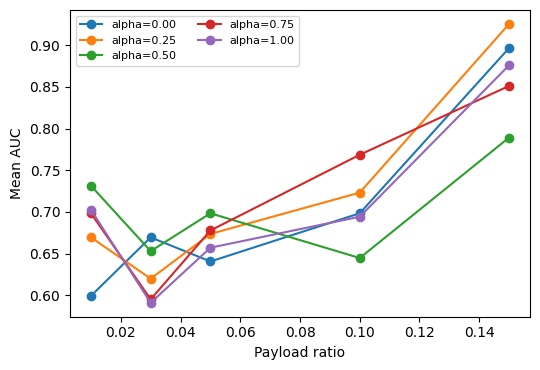

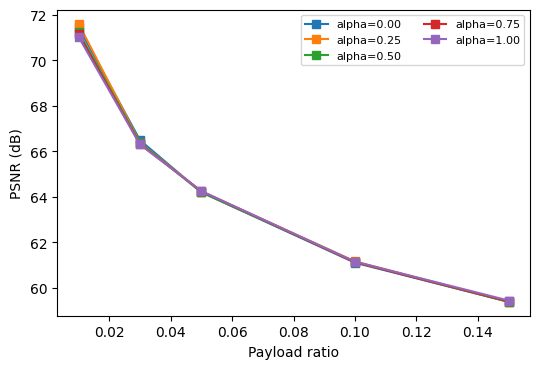

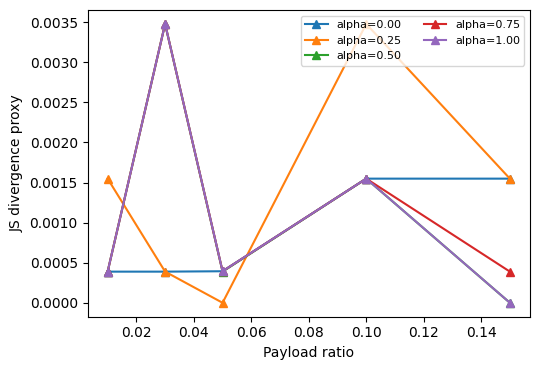

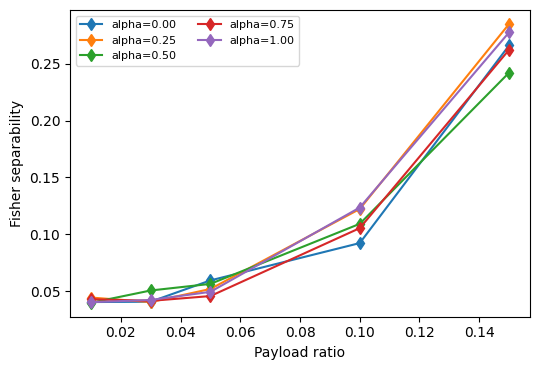

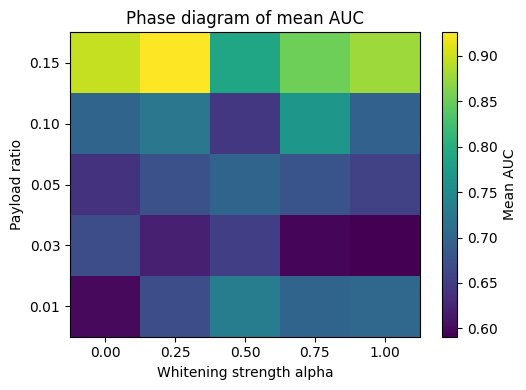

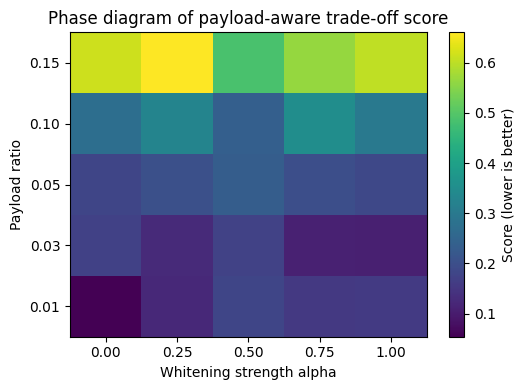

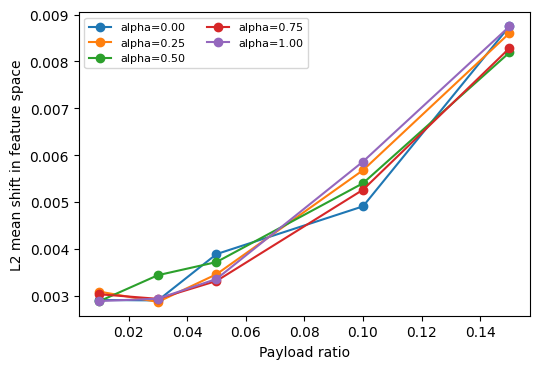

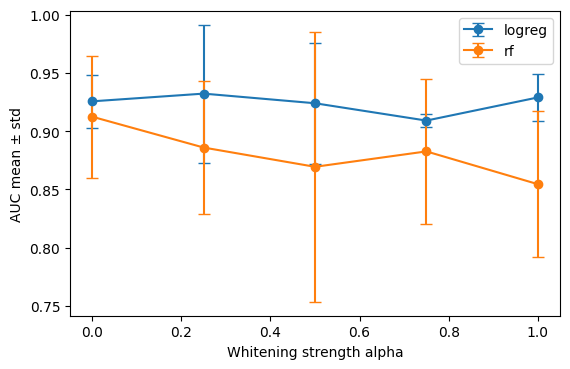

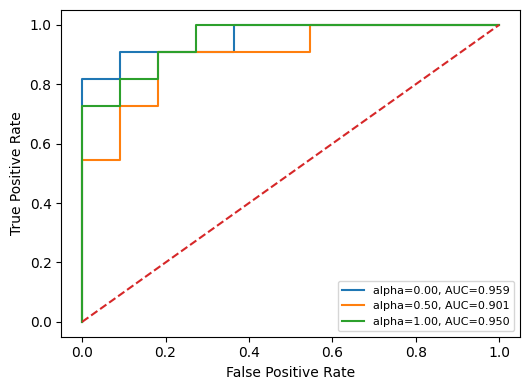

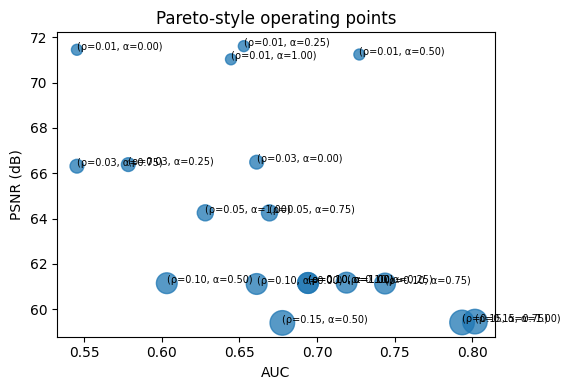

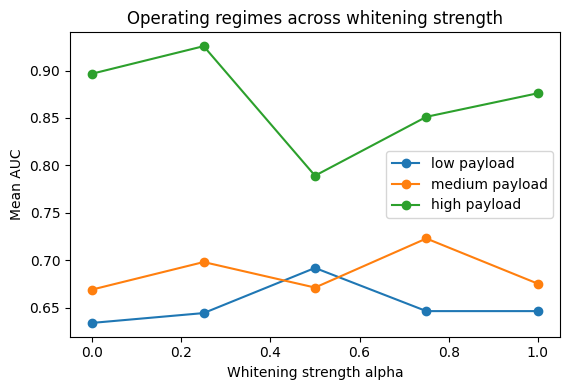

In [12]:
# Visualizations
plot_df = alpha_summary_df.copy()

plt.figure(figsize=(5.5, 3.8))
for alpha in CONFIG["alpha_grid"]:
    sub = plot_df[np.isclose(plot_df["alpha"], alpha)]
    plt.plot(sub["payload_ratio"], sub["auc"], marker="o", label=f"alpha={alpha:.2f}")
plt.xlabel("Payload ratio")
plt.ylabel("Mean AUC")
plt.legend(ncol=2, fontsize=8)
save_fig(FIG_DIR / "auc_vs_payload_alpha_v6.png")

plt.figure(figsize=(5.5, 3.8))
for alpha in CONFIG["alpha_grid"]:
    sub = plot_df[np.isclose(plot_df["alpha"], alpha)]
    plt.plot(sub["payload_ratio"], sub["psnr"], marker="s", label=f"alpha={alpha:.2f}")
plt.xlabel("Payload ratio")
plt.ylabel("PSNR (dB)")
plt.legend(ncol=2, fontsize=8)
save_fig(FIG_DIR / "psnr_vs_payload_alpha_v6.png")

plt.figure(figsize=(5.5, 3.8))
for alpha in CONFIG["alpha_grid"]:
    sub = plot_df[np.isclose(plot_df["alpha"], alpha)]
    plt.plot(sub["payload_ratio"], sub["js_lsb_mean"], marker="^", label=f"alpha={alpha:.2f}")
plt.xlabel("Payload ratio")
plt.ylabel("JS divergence proxy")
plt.legend(ncol=2, fontsize=8)
save_fig(FIG_DIR / "js_proxy_vs_payload_alpha_v6.png")

plt.figure(figsize=(5.5, 3.8))
for alpha in CONFIG["alpha_grid"]:
    sub = plot_df[np.isclose(plot_df["alpha"], alpha)]
    plt.plot(sub["payload_ratio"], sub["fisher_separation"], marker="d", label=f"alpha={alpha:.2f}")
plt.xlabel("Payload ratio")
plt.ylabel("Fisher separability")
plt.legend(ncol=2, fontsize=8)
save_fig(FIG_DIR / "fisher_vs_payload_alpha_v6.png")

# Phase diagram: AUC across payload ratio and whitening strength
phase_auc = alpha_summary_df.pivot(index="payload_ratio", columns="alpha", values="auc")
plt.figure(figsize=(5.4, 4.0))
plt.imshow(phase_auc.values, aspect="auto", origin="lower")
plt.xticks(range(len(phase_auc.columns)), [f"{a:.2f}" for a in phase_auc.columns])
plt.yticks(range(len(phase_auc.index)), [f"{r:.2f}" for r in phase_auc.index])
plt.xlabel("Whitening strength alpha")
plt.ylabel("Payload ratio")
plt.title("Phase diagram of mean AUC")
plt.colorbar(label="Mean AUC")
save_fig(FIG_DIR / "phase_diagram_auc_v6.png")

# Phase diagram: payload-aware tradeoff score
phase_tradeoff = alpha_summary_df.pivot(index="payload_ratio", columns="alpha", values="tradeoff_score_payload_aware")
plt.figure(figsize=(5.4, 4.0))
plt.imshow(phase_tradeoff.values, aspect="auto", origin="lower")
plt.xticks(range(len(phase_tradeoff.columns)), [f"{a:.2f}" for a in phase_tradeoff.columns])
plt.yticks(range(len(phase_tradeoff.index)), [f"{r:.2f}" for r in phase_tradeoff.index])
plt.xlabel("Whitening strength alpha")
plt.ylabel("Payload ratio")
plt.title("Phase diagram of payload-aware trade-off score")
plt.colorbar(label="Score (lower is better)")
save_fig(FIG_DIR / "phase_diagram_tradeoff_v6.png")

# Feature-space separability
plt.figure(figsize=(5.5, 3.8))
for alpha in CONFIG["alpha_grid"]:
    sub = divergence_df[np.isclose(divergence_df["alpha"], alpha)]
    plt.plot(sub["payload_ratio"], sub["mean_shift_l2"], marker="o", label=f"alpha={alpha:.2f}")
plt.xlabel("Payload ratio")
plt.ylabel("L2 mean shift in feature space")
plt.legend(ncol=2, fontsize=8)
save_fig(FIG_DIR / "feature_space_separability_v6.png")

# Robustness across seeds
plt.figure(figsize=(5.8, 3.8))
for model_name in CONFIG["warden_models"]:
    sub = seed_summary_df[
        np.isclose(seed_summary_df["payload_ratio"], CONFIG["stability_payload_ratios"][-1])
        & seed_summary_df["model"].eq(model_name)
    ].sort_values("alpha")
    plt.errorbar(sub["alpha"], sub["auc_mean"], yerr=sub["auc_std"], marker="o", capsize=4, label=model_name)
plt.xlabel("Whitening strength alpha")
plt.ylabel("AUC mean ± std")
plt.legend()
save_fig(FIG_DIR / "seed_stability_auc_v6.png")

# ROC comparison at the highest payload regime
ratio_ref = max(CONFIG["payload_ratios"])
plt.figure(figsize=(5.4, 4.0))
for alpha in CONFIG["alpha_representatives"]:
    roc_item = roc_cache[(ratio_ref, alpha, "logreg")]
    plt.plot(roc_item["fpr"], roc_item["tpr"], label=f"alpha={alpha:.2f}, AUC={roc_item['auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8)
save_fig(FIG_DIR / "roc_curve_alpha_comparison_v6.png")

# Pareto-style scatter: detectability vs fidelity, payload encoded by marker size
plt.figure(figsize=(5.8, 4.0))
sizes = 250 * (0.25 + pareto_df["payload_norm"].to_numpy())
plt.scatter(pareto_df["auc"], pareto_df["psnr"], s=sizes, alpha=0.75)
for _, row in pareto_df.iterrows():
    plt.annotate(f"(ρ={row['payload_ratio']:.2f}, α={row['alpha']:.2f})", (row["auc"], row["psnr"]), fontsize=7)
plt.xlabel("AUC")
plt.ylabel("PSNR (dB)")
plt.title("Pareto-style operating points")
save_fig(FIG_DIR / "pareto_auc_psnr_payload_v6.png")

# Regime summary plot
plt.figure(figsize=(5.8, 4.0))
for regime in ["low", "medium", "high"]:
    sub = regime_summary_df[regime_summary_df["payload_regime"].eq(regime)].sort_values("alpha")
    plt.plot(sub["alpha"], sub["auc_mean"], marker="o", label=f"{regime} payload")
plt.xlabel("Whitening strength alpha")
plt.ylabel("Mean AUC")
plt.title("Operating regimes across whitening strength")
plt.legend()
save_fig(FIG_DIR / "operating_regimes_auc_v6.png")


### 12. Artifact manifest, reproducibility summary, and notebook closure


In [13]:
# Final artifact export
artifact = {
    "title": "Adversarially-Resilient Covert Multimedia Communication via Quantum-Inspired Embedding and AI-Driven Warden Modeling",
    "version": "v6",
    "config": CONFIG,
    "output_dir": str(OUTPUT_DIR),
    "tables": [
        "smoke_test_results_v4.csv",
        "payload_alpha_sweep_results_v6.csv",
        "feature_divergence_results_v6.csv",
        "quality_metrics_results_v6.csv",
        "sender_warden_tradeoff_v6.csv",
        "alpha_summary_v6.csv",
        "phase_best_alpha_v6.csv",
        "phase_best_alpha_realistic_v6.csv",
        "pareto_front_v6.csv",
        "payload_regime_summary_v6.csv",
        "seed_stability_full_v6.csv",
        "seed_stability_summary_v6.csv",
    ],
    "figures": [
        "cover_image.png",
        "auc_vs_payload_alpha_v6.png",
        "psnr_vs_payload_alpha_v6.png",
        "js_proxy_vs_payload_alpha_v6.png",
        "fisher_vs_payload_alpha_v6.png",
        "phase_diagram_auc_v6.png",
        "phase_diagram_tradeoff_v6.png",
        "feature_space_separability_v6.png",
        "seed_stability_auc_v6.png",
        "roc_curve_alpha_comparison_v6.png",
        "pareto_auc_psnr_payload_v6.png",
        "operating_regimes_auc_v6.png",
    ],
}
save_json(artifact, OTHER_DIR / "artifact_manifest_v6.json")
append_summary("=== NOTEBOOK STATUS ===")
append_summary("Methodology-aligned and pedagogically structured notebook v6 created successfully.")
print(json.dumps(artifact, indent=2))


{
  "title": "Adversarially-Resilient Covert Multimedia Communication via Quantum-Inspired Embedding and AI-Driven Warden Modeling",
  "version": "v6",
  "config": {
    "image_size": 256,
    "payload_ratios": [
      0.01,
      0.03,
      0.05,
      0.1,
      0.15
    ],
    "alpha_grid": [
      0.0,
      0.25,
      0.5,
      0.75,
      1.0
    ],
    "alpha_representatives": [
      0.0,
      0.5,
      1.0
    ],
    "alpha_smoke": 0.5,
    "n_variants_per_ratio": 36,
    "test_size": 0.3,
    "whitening_seed": 123,
    "rf_estimators": 300,
    "warden_models": [
      "logreg",
      "rf"
    ],
    "save_figures": true,
    "basis_keep_prob": 0.62,
    "selector_jitter": 0.15,
    "position_shuffle_strength": 0.35,
    "analysis_seeds": [
      7,
      21,
      42,
      84,
      126
    ],
    "stability_payload_ratios": [
      0.1,
      0.15
    ],
    "payload_constraint_min": 0.05,
    "tradeoff_weights": {
      "auc": 0.4,
      "divergence": 0.25,
      "di